# Homework: Spectral Analysis Practice

This notebook gives you hands-on practice with the core ideas from the spectral analysis sessions, working entirely with toy signals you build yourself. Because you decide exactly what frequencies go into each signal, constructing your own signals is a great way to check that an analysis tool recovers what you expect and to get a better understanding of how the tool works before applying it to real data.

You will generate periodic signals (sinusoids, chirps, and sums of them), compute their power spectra with the Fourier transform, track time-varying frequency content with Morlet wavelets, and estimate spectra of noisy signals with multitapering.

## Setup

### Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import pywt

### Utility Functions

Run the cell below, but feel free to ignore this code — it’s some utility functions we’ll use later for convenience.

In [38]:
class utils:
    
    @staticmethod
    def style_plot(title, xlabel, ylabel):
        '''
        Styles plots displaying filters. Adds labels, grids and shows legends

        Args:
            title: title of plot
            xlabel: label x-axis
            ylabel: label y-axis
        '''
        
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.margins(0, 0.1)
        plt.grid(which='both', axis='both')
        plt.legend();

    @staticmethod
    def calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs: int = 100, bandwidth: float = 1.5, center_frequency: float = 1.0):
        '''
        Calculates the time-resolved spectrum of a signal using Morlet wavelets

        Args:
            sig: signal that the wavelet spectrum is calculated for
            sampling_frequency: sampling frequency of signal
            number_of_freqs: number of frequencies the wavelet spectrum is calculated for
            bandwidth: the bandwidth of the Morlet wavelet
            center_frequency: the central frequency of the Morlet wavelet
        Returns:
            freqs: frequencies for which the spectral values are calculated
            spectrum_amp: spectral amplitudes
        '''
        # the bandwidth and the central frequency sets which Morlet wavelet is used
        wavelet = "cmor"+str(bandwidth)+"-"+str(center_frequency)

        # widths of the Morlet wavelet determines which frequencies the wavelet spectrum is calculated for
        widths = np.logspace(start=3, stop=10, num=number_of_freqs, base=2)

        sampling_period = 1/sampling_frequency
        spectrum, freqs = pywt.cwt(sig, widths, wavelet, sampling_period=sampling_period)

        # take absolute value to get amplitude of spectrum
        spectrum_amp = np.abs(spectrum)

        return freqs, spectrum_amp
    
    @staticmethod
    def get_fft(data, time_vec):
        """
        Calculates the Fourier transform and frequencies of the transform for a signal
        """

        # Step 1: calculate the Fourier amplitude spectrum by taking the fourier transform of the signal
        fft_result = fft(data)

        # Step 2: Get all frequencies for which the Fourier amplitude spectrum was calculated in step 1
        freqs = fftfreq(len(data), d=(time_vec[1]-time_vec[0])) 

        # Step 3A: Extract positive frequencies only
        positive_freqs = freqs[freqs > 0]
        # Step 3B: Extract Fourier amplitude spectrum for positive frequencies only
        fft_result_positive = fft_result[freqs > 0]

        # Step 4: Get amplitude of spectrum and normalize it
        fft_amp_norm = np.abs(fft_result_positive)/np.abs(fft_result_positive).max()
        
        return positive_freqs, fft_amp_norm
    
    @staticmethod
    def plot_signal(sig, time_vec):
        """Makes plot of signal"""
        plt.figure()
        plt.plot(time_vec,sig)
        plt.title('Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')


## Generate Periodic signals

It's often useful to construct toy signals when doing signal analysis. Toy signals allow you to test the tools you use to make sure that you are using them correctly and to understand how they work before applying them to real data. This section provides a hands-on introduction to creating and visualizing toy signals using the `scipy.signal` module. 

| Code | Description |
|---|---|
| `np.pi`| The mathematical constant π. |
| `np.linspace(start, stop, n)` | Generates an array of `n` evenly spaced values from `start` to `stop`. |
| `np.arange(start, stop, step_size)` | Generates an array of values evenly spaced from `start` to `stop`, with the spacing given by `step_size` |
| `np.sin(2*np.pi*f*time_vec + phase)` | Generates a sine wave oscillating with a frequency `f` over a time period `time_vec` (a vector of time points) |
| `signal.chirp(time_vec, f0, f1, t1)` | Generates a chirp signal, which is a signal where the frequency changes over time. |
| `plt.plot(x, y)` | Plots the data in `y` against the corresponding values in `x`. |

#### **Exercises**

**Example**: Generate and plot a sinusoid signal lasting 1 second with a frequency of 5 Hz.

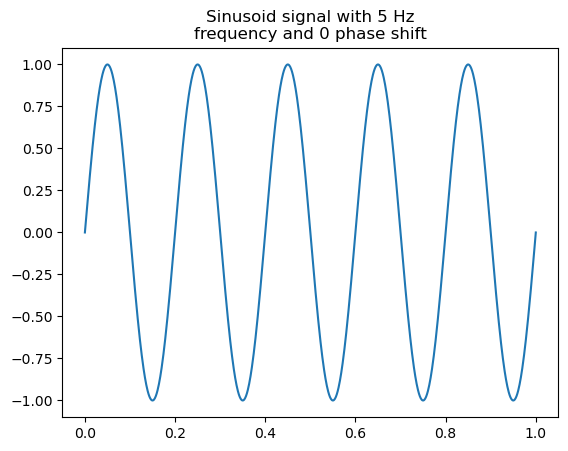

In [39]:
# Generate signal
duration = 1 # second
sampling_frequency = 1000
time_vec = np.linspace(0,duration,int(sampling_frequency*duration)) # seconds

frequency = 5 # Hz
phase = 0
sig = np.sin(2*np.pi*frequency*time_vec+phase)

plt.figure()
plt.plot(time_vec,sig)
plt.title(f'Sinusoid signal with {frequency} Hz\nfrequency and 0 phase shift');

**Exercise**: Generate and plot a sinusoid signal lasting 1 second with a frequency of 5 Hz and a phase of $\pi/2$.

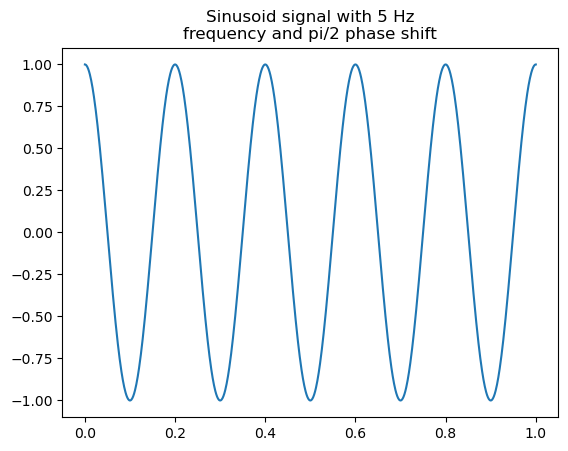

In [40]:
duration = 1 # second
sampling_frequency = 1000
time_vec = np.linspace(0,duration,int(sampling_frequency*duration)) # seconds

frequency = 5 # Hz
phase = np.pi/2
sig = np.sin(2*np.pi*frequency*time_vec+phase)

plt.figure()
plt.plot(time_vec, sig)
plt.title(f'Sinusoid signal with {frequency} Hz\nfrequency and pi/2 phase shift');

**Exercise**: Generate and plot a sinusoid signal lasting 1 second with a frequency of 20 Hz and a phase of 0.

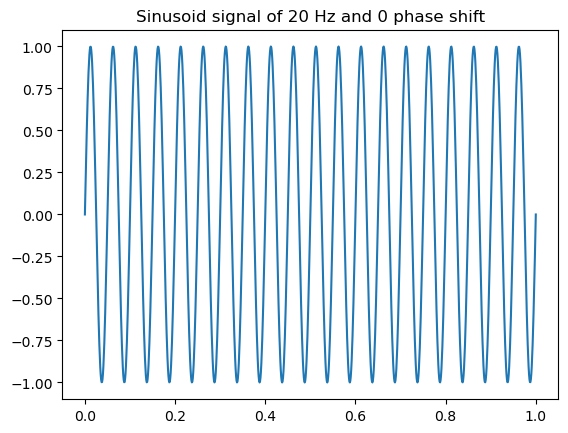

In [41]:
duration = 1 # second
sampling_frequency = 1000
time_vec = np.linspace(0,duration,int(sampling_frequency*duration)) # seconds

frequency = 20 # Hz
phase = 0
sig = np.sin(2*np.pi*frequency*time_vec+phase)

plt.figure()
plt.plot(time_vec, sig)
plt.title(f'Sinusoid signal of {frequency} Hz and 0 phase shift');

**Exercise**: Generate and plot a chirp signal that starts at a frequency of 1 Hz and increases to 10 Hz over a period of 1 second.

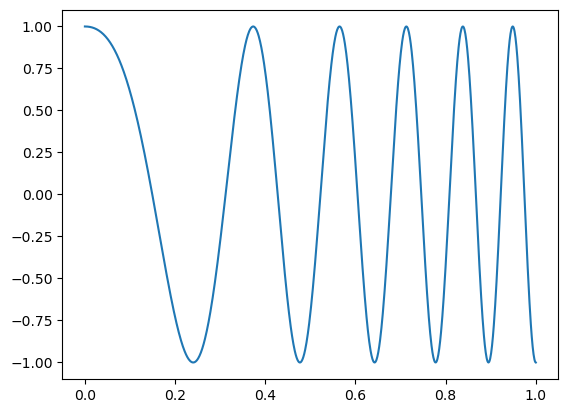

In [42]:
duration = 1 # second
sampling_frequency = 1000
time_vec = np.linspace(0,duration,int(sampling_frequency*duration)) # seconds

sig = signal.chirp(time_vec, f0=1, f1=10, t1=1)
plt.plot(time_vec, sig);

**Exercise**: Generate and plot a chirp signal that starts at a frequency of 5 Hz and increases to a frequency of 15 Hz over a period of 1 second.

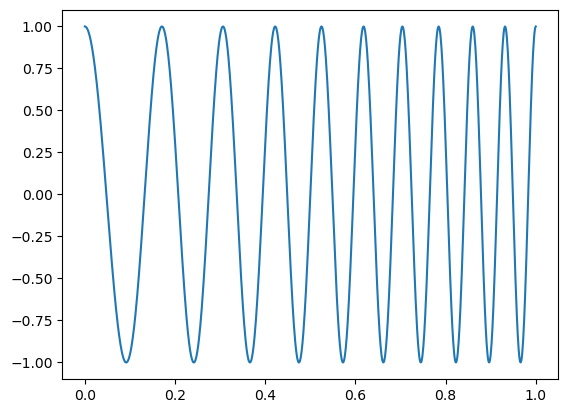

In [43]:
duration = 1 # second
sampling_frequency = 1000
time_vec = np.linspace(0,duration,duration*sampling_frequency) # seconds
sig = signal.chirp(time_vec, f0=5, f1=15, t1=duration)

plt.plot(time_vec, sig);

**Exercise**: Generate and plot a chirp signal that *starts* at a frequency of 20 Hz and *decreases* to a frequency of 2 Hz over a period of 3 seconds.

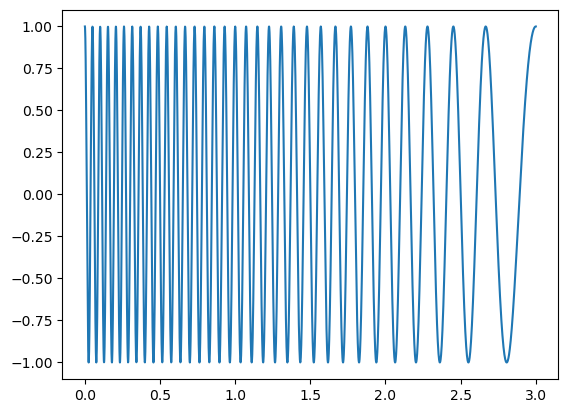

In [44]:
duration = 3 # second
sampling_frequency = 1000
time_vec = np.linspace(0,duration,int(sampling_frequency*duration)) # seconds

sig = signal.chirp(time_vec, f0=20, f1=2, t1=duration)

plt.plot(time_vec, sig);

**Example**: Generate and plot a composite signal that is a sum of a chirp signal that starts at a frequency of 1 Hz and increases to 10 Hz over a duration of 1 second and a sine wave with frequency of 5 Hz and phase 0.

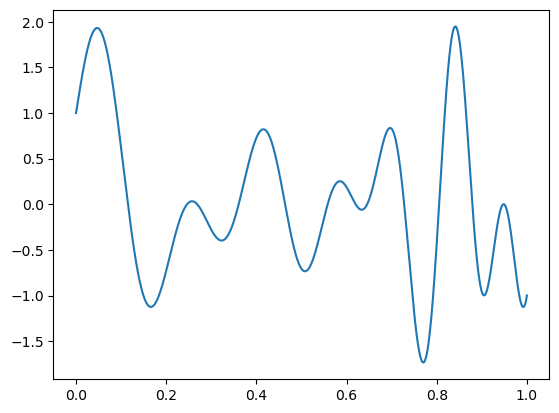

In [45]:
# Generate signal
duration = 1
sampling_frequency = 1000
time_vec = np.linspace(0,duration,sampling_frequency) # seconds
frequency = 5 # Hz
phase = 0
sine_signal = np.sin(2*np.pi*frequency*time_vec+phase)

chirp_signal = signal.chirp(time_vec, f0=1, f1=10, t1=duration)

composite_signal = sine_signal + chirp_signal
plt.plot(time_vec, composite_signal);

**Exercise**: Generate and plot a composite signal that is a sum of a chirp signal that starts at a frequency of 2 Hz and increases to 20 Hz over a duration of 1 second and a sine wave with frequency of 5 Hz and phase $\pi/2$.

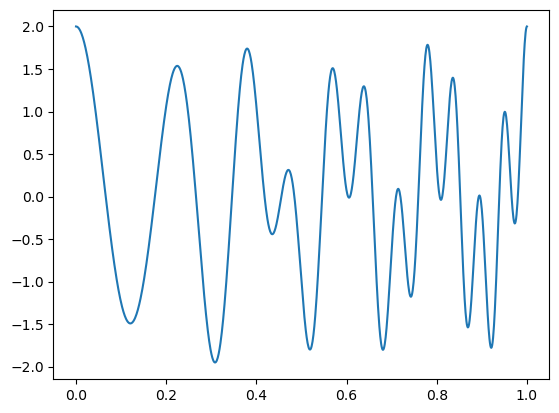

In [46]:
# Generate signal
duration = 1
time_vec = np.linspace(0,duration,1000) # seconds
frequency = 5 # Hz
phase = np.pi/2
sine_signal = np.sin(2*np.pi*frequency*time_vec+phase)

chirp_signal = signal.chirp(time_vec, f0=2, f1=20, t1=duration)

composite_signal = sine_signal + chirp_signal
plt.plot(time_vec, composite_signal);

## Calculate the Total Frequency Content of a Signal with the Fourier Transform

The Fourier transform is a standard way of calculating the frequency amplitude spectrum of a signal. Here, you will apply the Fourier transform to different toy signals to get a better intuition for the relationship between peaks in the Fourier amplitude spectrum and oscillations in your original signal.

| Code | Description |
| :-- | :-- |
| `freq, fft_amp = utils.get_fft(sig, times_sampled)` | Calculate the Fourier amplitude spectrum of a signal `sig` with the Fourier transform. `times_sampled` contains the time points at which the signal was sampled. |
| `utils.plot_signal(sig, times_sampled)` | Plots the signal `sig` against the time points the signal was sampled ``times_sampled`` |
| `plt.plot(x, y)` | Plot y values against x values. |
| `plt.xlim([some_lower_xlim, some_upper_xlim])`                 | Limit the x-axis in a plot to be between the numbers ``some_lower_xlim`` and ``some_upper_xlim``. |

#### **Exercises**

Run the cell below to generate a sinusoid signal oscillating at ``5`` Hz.

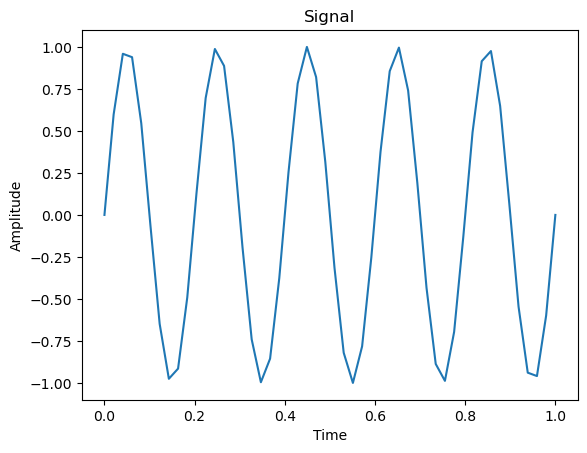

In [47]:
# provided

# Generate sine signal
time_vec = np.linspace(0,1,50) # seconds
frequency = 5 # Hz
sine = np.sin(2*np.pi*frequency*time_vec)

utils.plot_signal(sine, time_vec)

**Example**: Calculate the Fourier amplitude spectrum for the sinusoid signal generated above. Plot the spectrum.

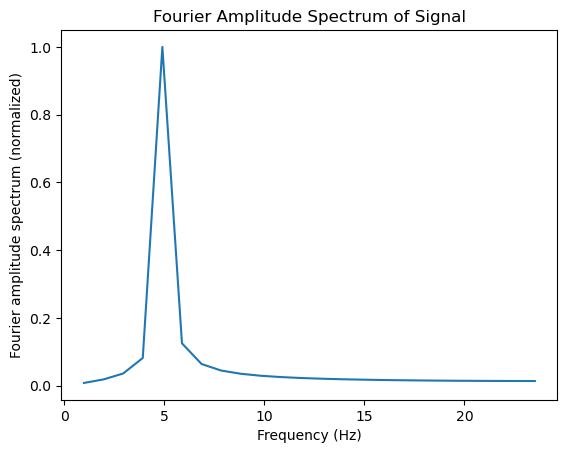

In [48]:
freqs, psd = utils.get_fft(sine, time_vec)

plt.plot(freqs,psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fourier amplitude spectrum (normalized)')
plt.title('Fourier Amplitude Spectrum of Signal');

Run the cell below to generate a sinusoid signal oscillating at ``20`` Hz.

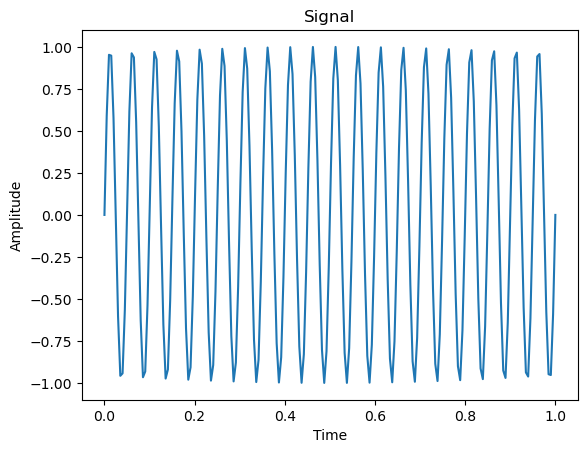

In [49]:
# Generate signal
time_vec = np.linspace(0,1,200) # seconds
frequency = 20 # Hz
sine = np.sin(2*np.pi*frequency*time_vec)

utils.plot_signal(sine, time_vec)

**Exercise**: Use the `utils.get_fft` function to calculate the Fourier amplitude spectrum for the sinusoid signal generated above. Plot the spectrum.

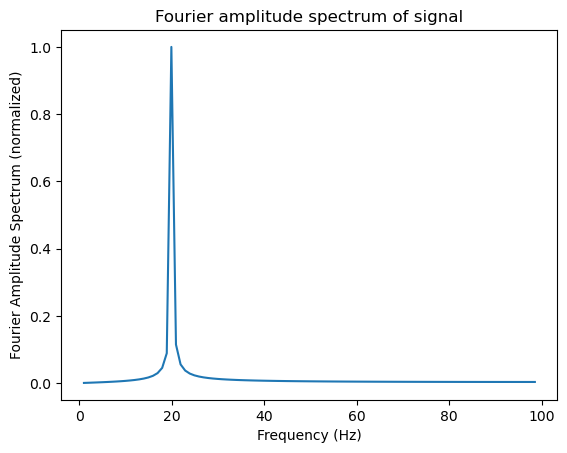

In [50]:
freqs, psd = utils.get_fft(sine, time_vec)

plt.plot(freqs,psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fourier Amplitude Spectrum (normalized)')
plt.title('Fourier amplitude spectrum of signal');

Run the cell below to generate a composite signal consisting of two sinusoids.

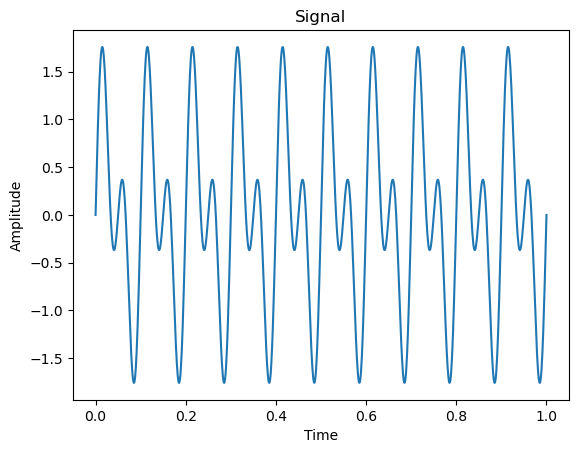

In [51]:
# provided

# Create composite signal

sampling_frequency = 1000
time_vec = np.linspace(0,1,sampling_frequency) # seconds
frequencyA = 10 # Hz
sineA = np.sin(2*np.pi*frequencyA*time_vec)

frequencyB = 20 # Hz
sineB = np.sin(2*np.pi*frequencyB*time_vec)

composite_signal = sineA+sineB

utils.plot_signal(composite_signal, time_vec)

**Exercise**: Calculate Fourier amplitude spectrum for the composite signal above. Plot the spectrum.

When you calculate the Fourier amplitude spectrum with the `utils.get_fft` function, note that the variable containing the composite signal is called `composite_signal`.

Which frequencies do the two sinusoids that make up the composite signal oscillate at?

**Hint**: If the spectral peaks are all to the left in the plot, you can limit the x-axis to focus on them by adding the line `plt.xlim([lower_limit, upper_limit])` (insert numbers for `lower_limit` and `upper_limit`).

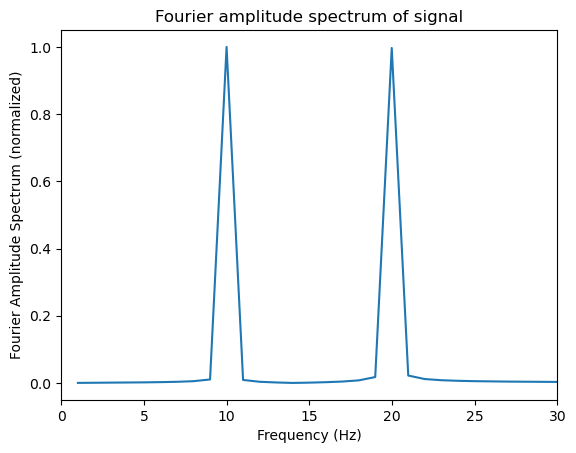

In [52]:
freqs, psd = utils.get_fft(composite_signal, time_vec)

plt.plot(freqs,psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fourier Amplitude Spectrum (normalized)')
plt.title('Fourier amplitude spectrum of signal')
plt.xlim([0, 30]);

Run the cell below to generate a chirp signal that is gradually increasing its frequency from 1 to 15 Hz.

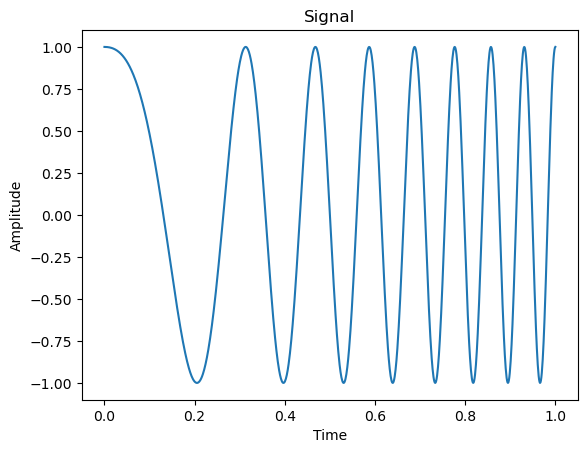

In [53]:
# provided

sampling_frequency = 1000
time_vec = np.linspace(0,1,sampling_frequency) # seconds

# generate chirp signal
chirp_signal = signal.chirp(time_vec, f0=1, f1=15, t1=1)

utils.plot_signal(chirp_signal, time_vec)

**Exercise**: Calculate and plot the Fourier amplitude spectrum for the chirp signal (`chirp_signal`) generated above. Is the region of the spectrum with most power where you would expect given how the signal was constructed?

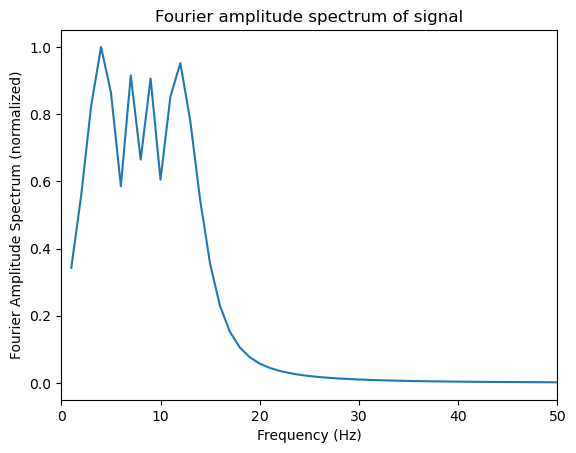

In [54]:
freqs, psd = utils.get_fft(chirp_signal, time_vec)

plt.plot(freqs,psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fourier Amplitude Spectrum (normalized)')
plt.title('Fourier amplitude spectrum of signal')
plt.xlim([0, 50]);

Run the cell below to generate a composite signal consisting of a sine wave with a 30 Hz frequency and a chirp signal increasing from 1 to 15 Hz.

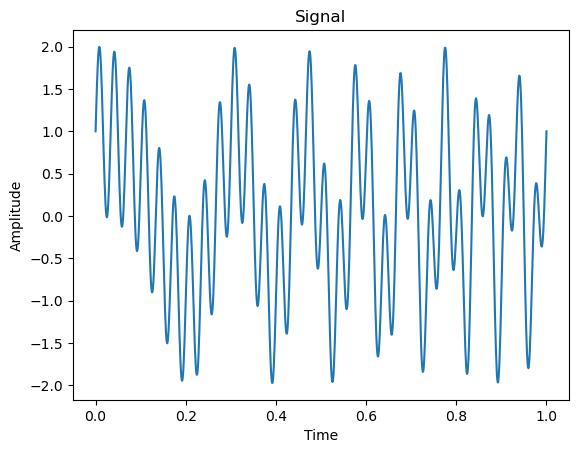

In [55]:
# Create composite signal

sampling_frequency = 1000
time_vec = np.linspace(0,1,sampling_frequency) # seconds

# set frequency of sine wave and generate it
frequency = 30 # Hz
sineA = np.sin(2*np.pi*frequency*time_vec)

# generate chirp signal
chirp_signal = signal.chirp(time_vec, f0=1, f1=15, t1=1)

# create composite signal by summing sine wave and chirp signal
composite_signal = sineA+chirp_signal

utils.plot_signal(composite_signal, time_vec)

**Exercise**: Use the ``get_fft`` function to calculate Fourier amplitude spectrum for the composite signal generated above. Plot the spectrum.

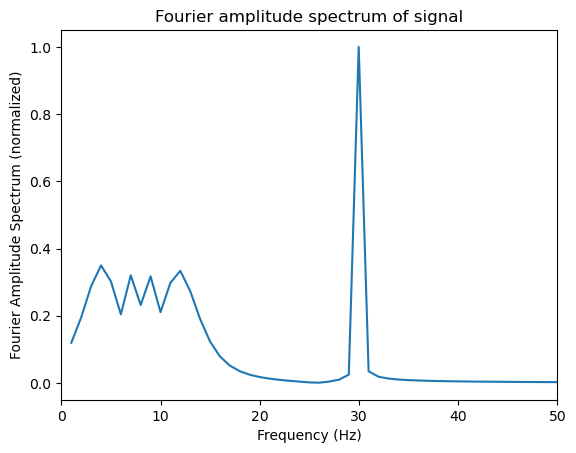

In [56]:
freqs, psd = utils.get_fft(composite_signal, time_vec)

plt.plot(freqs, psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fourier Amplitude Spectrum (normalized)')
plt.title('Fourier amplitude spectrum of signal')
plt.xlim([0, 50]);

## Time-resolved frequency analysis with Morlet wavelets

One important and frequently used method for computing time-resolved frequency spectra is the Morlet wavelet transform. Morlet wavelets are wavelets with specific frequencies, and the process of convolving them with the signal can be seen as a matching process. You check how well the frequency of the signal matches with the frequency of the Morlet wavelet at a given time point. The better the match is, the higher the power will be for that frequency at that time point in the Fourier amplitude spectrum. The plot below illustrates a Morlet wavelet whose frequency matches the frequency of the signal.

![](img/morlet_wavelet_matching_signal_illustration.png)

| Code | Description |
| :-- | :-- |
| `freqs, spectrum_amp = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)` | Calculates the wavelet spectrum `spectrum` for a signal `sig` with a given `sampling_frequency`. `number_of_freqs` sets the number of frequencies the spectrum is calculated for. `bandwidth` and `center_frequency` sets the parameters for the Morlet wavelet. |
| `plt.pcolormesh(x, y, C, cmap = 'plasma', shading = 'gouraud')` | Make a 2D colormap of values in a 2D array (C) against x and y values. The optional parameters ``cmap`` and `shading` define the colormap and the interpolation applied to the plot, respectively. |

#### **Exercises**

Run the cell below to generate a signal that changes its frequency from 5 Hz to 15 Hz at the midpoint of the recording period.

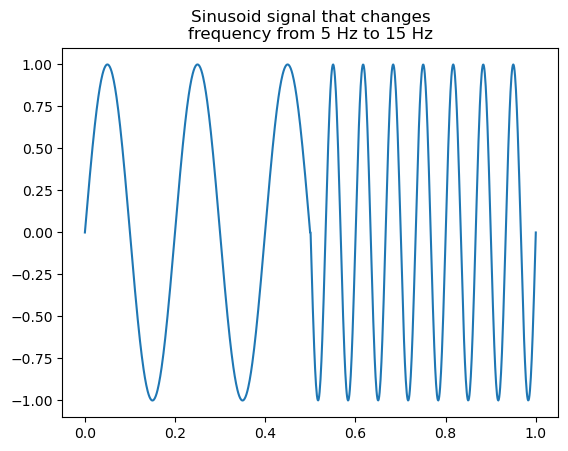

In [57]:
# provided

# Generate signal
sampling_frequency = 1000
durationA = 0.5
time_vecA = np.linspace(0,durationA,int(sampling_frequency*durationA)) # seconds
frequencyA = 5 # Hz
sineA = np.sin(2*np.pi*frequencyA*time_vecA)

durationB = 0.5
time_vecB = np.linspace(durationA, durationA+durationB, int(sampling_frequency*durationB)) # seconds
frequencyB = 15 # Hz
sineB = np.sin(2*np.pi*frequencyB*time_vecB)

time_vec = np.linspace(0,durationA+durationB,int(sampling_frequency*(durationA+durationB)))
sig = np.concatenate([sineA,sineB])

plt.figure()
plt.plot(time_vec,sig)
plt.title(f'Sinusoid signal that changes\nfrequency from {frequencyA} Hz to {frequencyB} Hz');

**Example**: Calculate the time-resolved spectrum for the constructed signal below using a Morlet wavelet. Plot the resulting spectrum using the `pcolormesh` function.

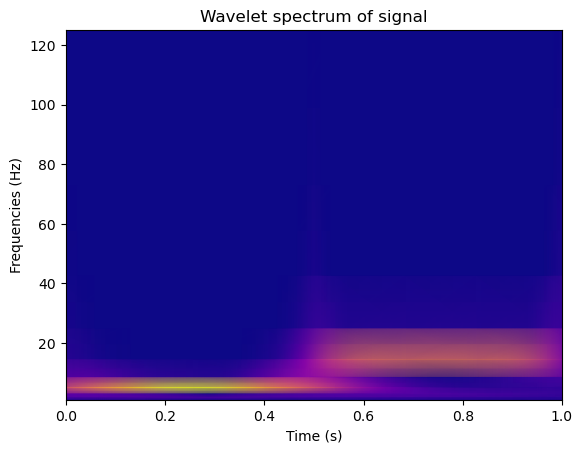

In [58]:
# solution

number_of_freqs = 10
bandwidth = 1.5
center_frequency = 1.0
freqs, spectrum = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)

plt.pcolormesh(time_vec, freqs, spectrum, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

**Exercise**: Calculate the time-resolved Fourier amplitude spectrum for the same constructed sinusoid below using a Morlet wavelet. But this time change the `number_of_freqs` to ``100``. This parameter specifies how many frequencies to calculate the spectrum for. Plot the result using the `pcolormesh` function. 

What happens to the frequency resolution when you compare to the plot above?

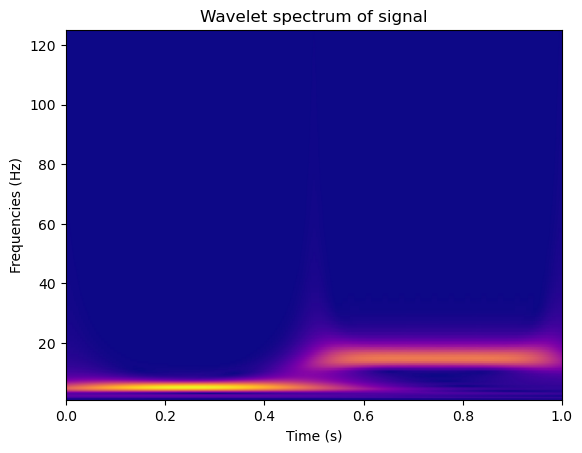

In [59]:
number_of_freqs = 100
bandwidth = 1.5
center_frequency = 1.0
freqs, spectrum = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)

plt.pcolormesh(time_vec, freqs, spectrum, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

The Morlet wavelet comes in many different shapes and sizes. There are two parameters that determine which kind of Morlet wavelet is used in the calculation of the spectrum: the ``bandwidth`` and the ``center frequency`` of the wavelet. The ``bandwidth`` determines how **broad** the wavelet is and the ``center frequency`` determines **how many oscillations** it has. Wavelets with different bandwidths and center frequencies are illustrated in the figure below. These two parameters determine the frequency- and time-resolution of the resulting spectrum.

![](img/different_morlet_wavelet_illustrations.png)

**Exercise**: Calculate the time-resolved spectrum for the same constructed sinusoid below using a Morlet wavelet. Keep the `number_of_freqs` parameter at 100, but change the ``center_frequency`` parameter to 0.5.

What happens to the frequency resolution now?

**Note**: The vertical, periodic stripes you see in the plot are just due to the discontinuity in the signal when it jumps from 5 to 15 Hz in the middle.

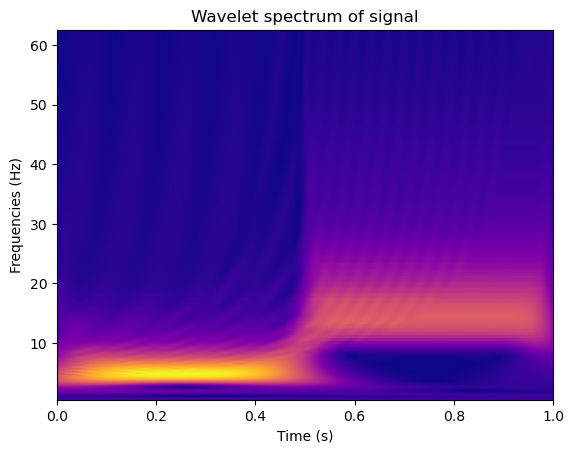

In [60]:
number_of_freqs = 100
bandwidth = 1.5
center_frequency = 0.5
freqs, spectrum = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)

plt.pcolormesh(time_vec, freqs, spectrum, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

**Exercise**: Change the ``center_frequency`` parameter to 2.0. Calculate and plot the time-resolved spectrum for the same constructed sinusoid below using a Morlet wavelet.

What happens to the frequency resolution? What happens to the time resolution?

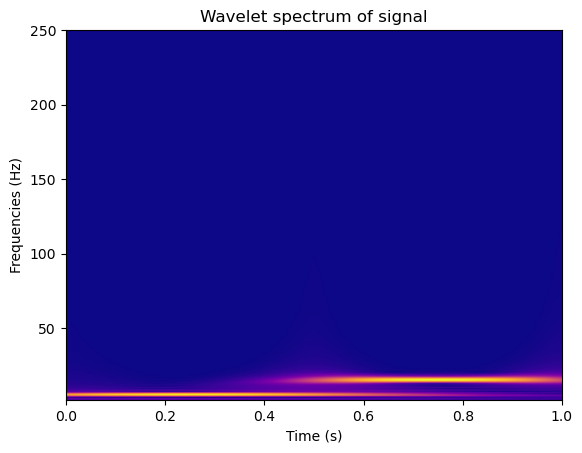

In [33]:
number_of_freqs = 100
bandwidth = 1.5
center_frequency = 2.0
freqs, spectrum = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)

plt.pcolormesh(time_vec, freqs, spectrum, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

**Exercise**: Set the ``center_frequency`` parameter back to ``1.0``, but change the ``bandwidth`` parameter to ``0.5``. Calculate and plot the time-resolved spectrum for the same constructed sinusoid again.

What happens to the frequency resolution this time?

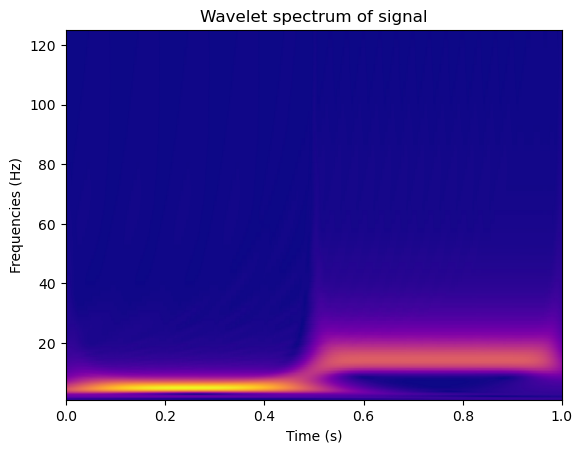

In [34]:
number_of_freqs = 100
bandwidth = 0.5
center_frequency = 1.0
freqs, spectrum = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)

plt.pcolormesh(time_vec, freqs, spectrum, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

**Exercise**: Change the ``bandwidth`` of the wavelet to ``2.5``. Calculate and plot the spectrum using `pcolormesh`.

What happens to the frequency resolution compared to the last plot?

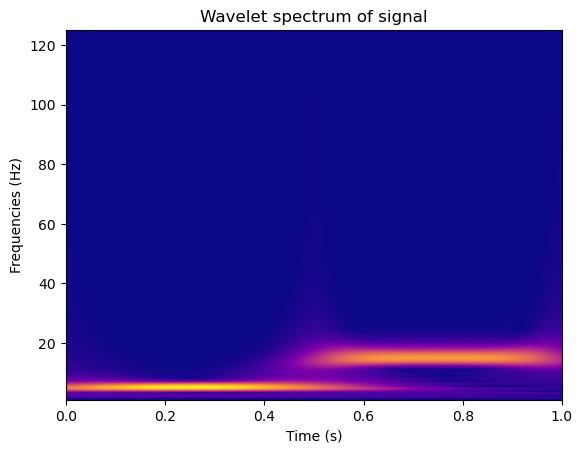

In [35]:
number_of_freqs = 100
bandwidth = 2.5
center_frequency = 1.0
freqs, spectrum = utils.calc_wavelet_spectrum(sig, sampling_frequency, number_of_freqs, bandwidth, center_frequency)

plt.pcolormesh(time_vec, freqs, spectrum, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

**Comment**: The exercises and plots above should demonstrate that if you increase the time resolution, you decrease the frequency resolution in your spectrum. And vice versa, if you increase the frequency resolution, you decrease the time resolution of your spectrum. There's a fundamental trade-off between resolution in frequency and resolution in time.

The different parameters used for the Morlet wavelet determine where you strike the balance between frequency and time resolution. The frequency resolution increases and the time resolution goes down with greater bandwidth or greater center frequency.

## Multitapering

Multitapering is a method to reduce noise in your spectrum through averaging across multiple spectra. With multitapering, your signal is multiplied with different "tapers", as they are called (illustrated in panel B in the figure below) and the Fourier transform is calculated for each of the tapered signals to get a collection of power spectra. In the end, these power spectra are averaged to produce the total power spectrum (panel E).

![](img/multitapering_illustration.png)

From: Analyzing Neural Time Series, Chapter 16: Multitapers, Mike Cohen.

| Code | Description |
| :-- | :-- |
| `freqs, psd_mt, _ = multi_taper_psd(sig, Fs)` | Calculate the power spectral density using multitapering. `Fs` is the sampling frequency. |
| `plt.plot(x, y)` | Plot y values against x values. |
| `plt.xlim([some_lower_xlim, some_upper_xlim])`                 | Limit the x-axis in a plot to be between the numbers ``some_lower_xlim`` and ``some_upper_xlim``. |

#### **Exercises**

In [36]:
from nitime.algorithms import multi_taper_psd

Run the cell below to generate a signal.

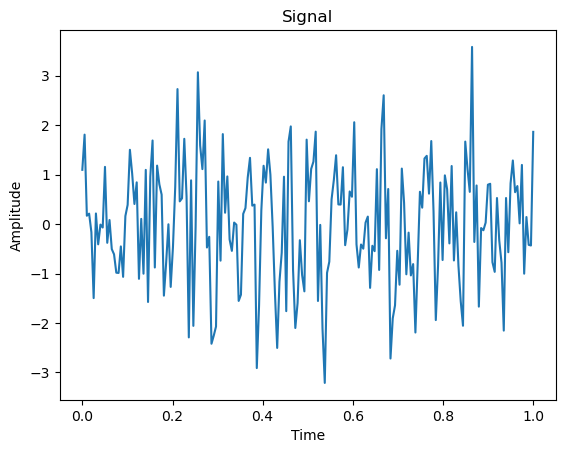

In [37]:
# provided

# Generate signal
sampling_frequency = 200 # sampling frequency (Hz)
duration = 1 # seconds
time_vec = np.linspace(0,duration,sampling_frequency) # seconds
frequency = 20 #
pure_sine = np.sin(2*np.pi*frequency*time_vec)

# generate noise
noise = np.random.normal(0,1,len(time_vec))

# add noise to sine wave
sine = pure_sine + noise

utils.plot_signal(sine, time_vec)

**Example**: Use the multitapering method to calculate the spectrum for the signal generated above. Plot the power spectrum against frequencies.

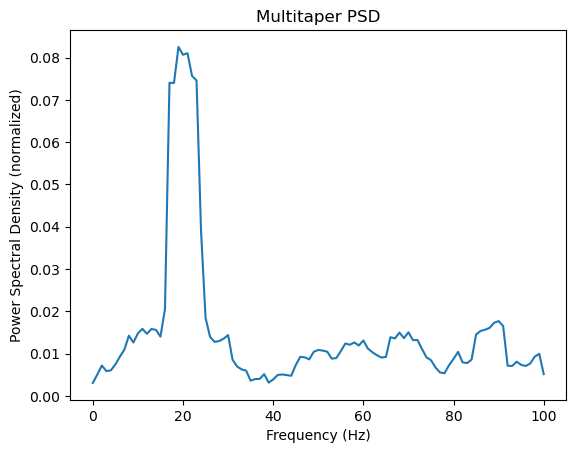

In [ ]:
# solution

freqs, psd_mt, _ = multi_taper_psd(sine, Fs=sampling_frequency)

# Plot the result
plt.figure()
plt.plot(freqs, psd_mt)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Multitaper PSD');

Run the cell below to generate a composite signal.

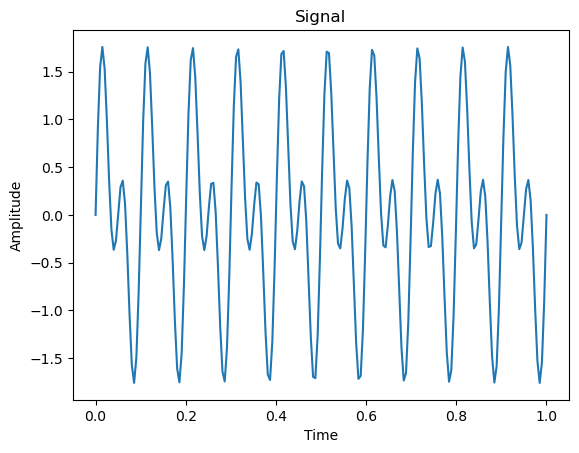

In [39]:
# provided 

# Create composite signal
sampling_frequency = 200
time_vec = np.linspace(0,1,sampling_frequency) # seconds
frequencyA = 10 # Hz
sineA = np.sin(2*np.pi*frequencyA*time_vec)

frequencyB = 20 # Hz
sineB = np.sin(2*np.pi*frequencyB*time_vec)

composite_signal = sineA+sineB

utils.plot_signal(composite_signal, time_vec)

**Exercise**: Use the multitapering method to calculate the spectrum for the composite signal above consisting of two sine waves with frequencies 10 Hz and 20 Hz. Plot the result.

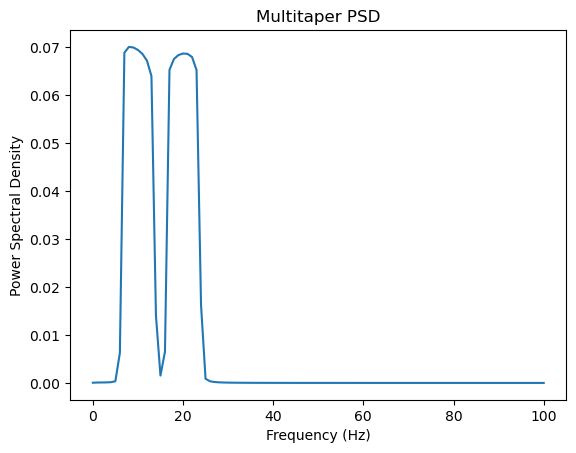

In [40]:
freqs, psd_mt, _ = multi_taper_psd(composite_signal, sampling_frequency)

plt.plot(freqs, psd_mt)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Multitaper PSD');

Run the cell below to generate a new composite signal.

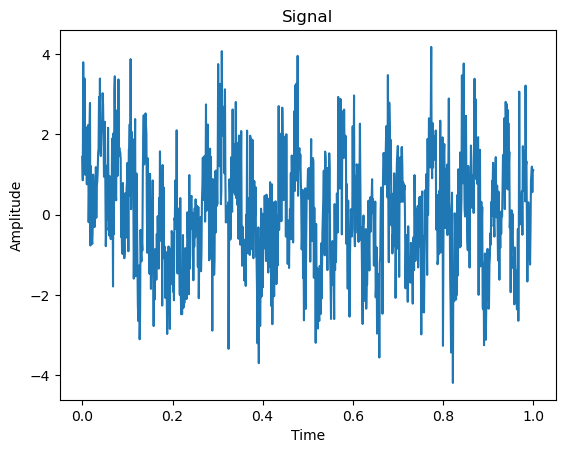

In [41]:
# provided

# Create composite signal
sampling_frequency = 1000
time_vec = np.linspace(0,1,sampling_frequency) # seconds
frequency = 30 # Hz
sineA = np.sin(2*np.pi*frequency*time_vec)

chirp_signal = signal.chirp(time_vec, f0=1, f1=15, t1=1)

np.random.seed(5)
noise = np.random.normal(0,1,len(time_vec))

composite_signal = sineA+chirp_signal+noise

utils.plot_signal(composite_signal, time_vec)

**Exercise**: Use the multitapering method to calculate the spectrum for the composite signal generated above consisting of a sine wave with frequency 30 Hz, a chirp signal, and noise. Plot the spectrum against frequencies. 

**Hint**: If the spectral peaks are all to the left in the plot, you can limit the x-axis to focus on them using `plt.xlim([lower_limit, upper_limit])` (insert numbers for `lower_limit` and `upper_limit`).

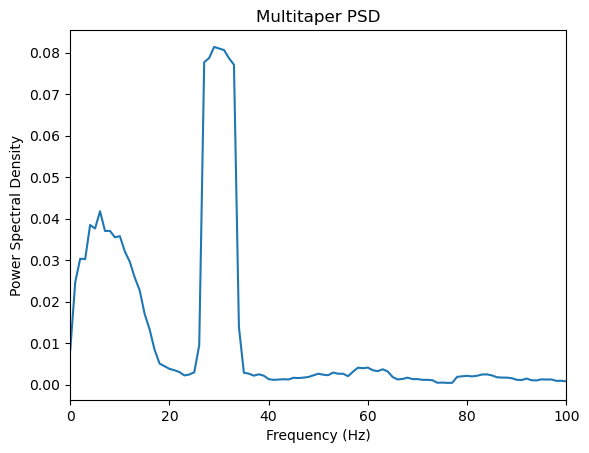

In [42]:
freqs, psd_mt, _ = multi_taper_psd(composite_signal, sampling_frequency)

plt.plot(freqs, psd_mt)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Multitaper PSD')
plt.xlim([0,100]);